In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [76]:
df=pd.read_csv('height-weight.csv')

In [77]:
df.head()

,Weight,height,age
0,42,160,26
1,69,195,38
2,63,151,40
3,69,187,39
4,81,182,39


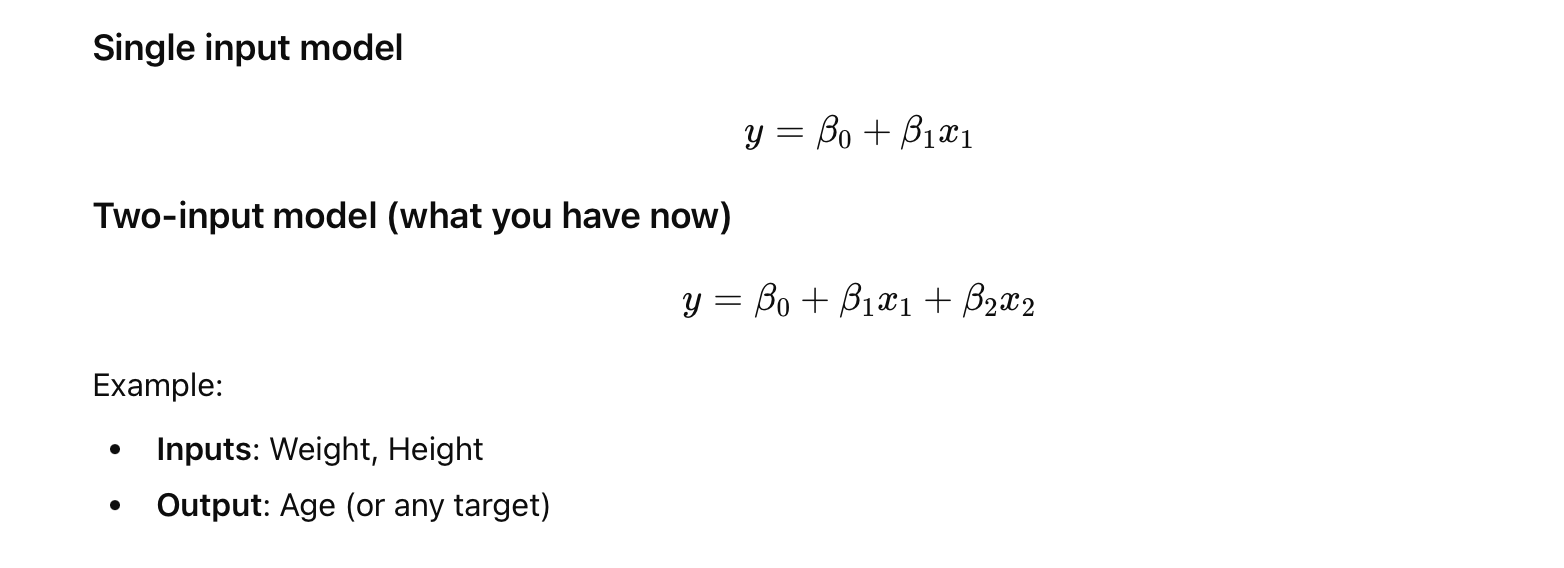

Text(0, 0.5, 'age')

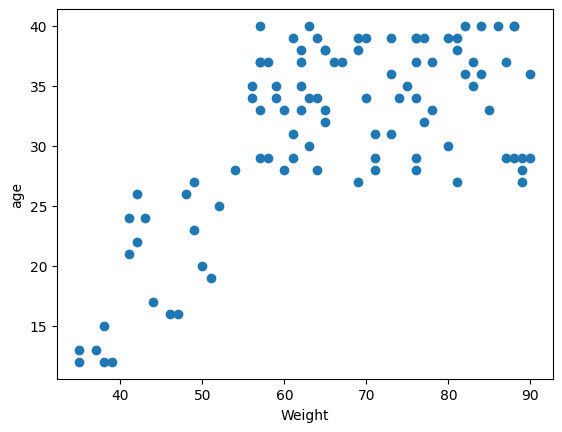

In [78]:
##scatter plot
plt.scatter(df['Weight'],df['age'])
plt.xlabel("Weight")
plt.ylabel("age")

In [79]:
## Correlation
df.corr()

,Weight,height,age
Weight,1.000000,0.770491,0.654360
height,0.770491,1.000000,0.486387
age,0.654360,0.486387,1.000000


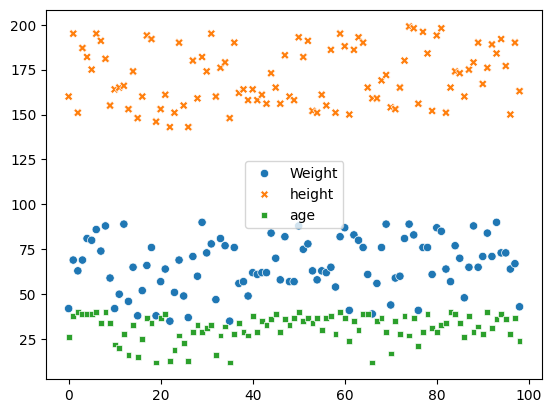

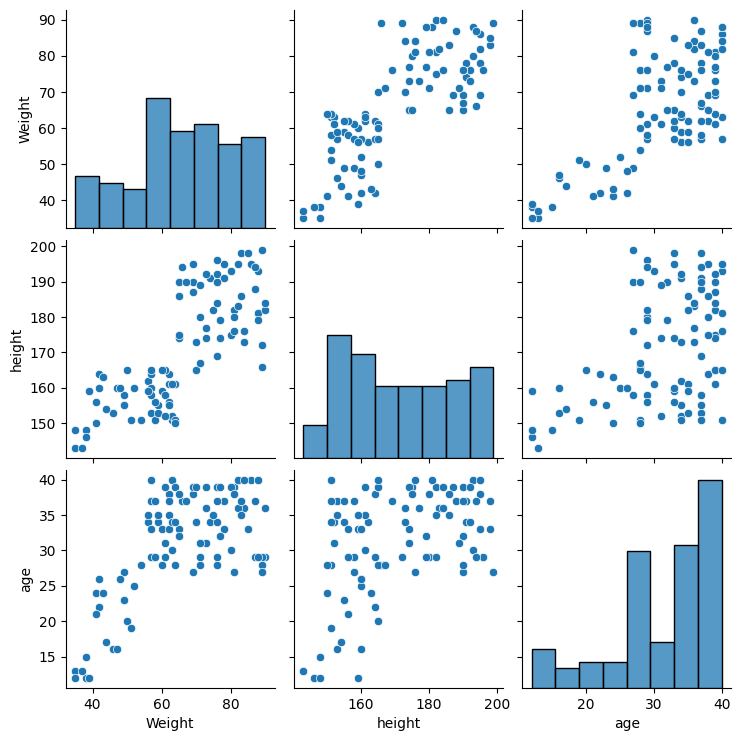

In [82]:
## Seaborn for visualization
import seaborn as sns
sns.scatterplot(df)
sns.pairplot(df)

In [83]:
## Independent and dependent features
X=df[['Weight']] ### independent features should be data frame or 2 dimesnionalarray
y=df['age'] ## this variiable can be in series or 1d array


In [84]:
X_series=df['Weight']
np.array(X_series).shape

(99,)

In [85]:
np.array(y).shape

(99,)

In [86]:
## Train Test Split
from sklearn.model_selection import train_test_split


In [87]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [88]:
X_test

,Weight
62,83
40,62
95,73
18,76
97,67
84,77
64,76
42,62
10,42
0,42


In [89]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [90]:
regression=LinearRegression()

In [91]:
regression.fit(X_train,y_train)

LinearRegression()

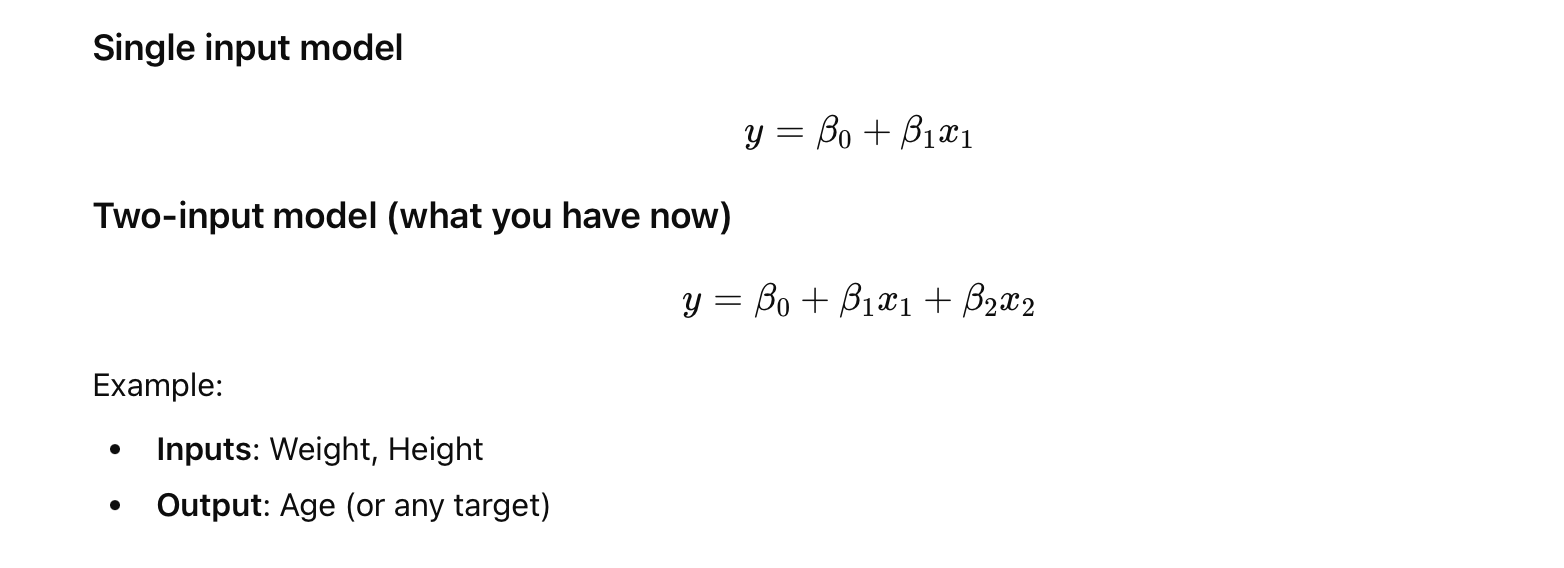

In [92]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [0.29884854]
Intercept: 11.73312666076173


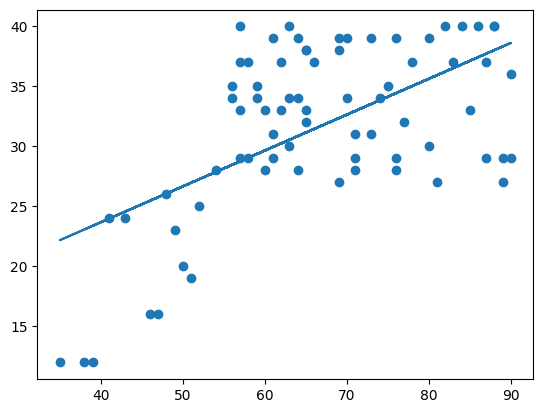

In [94]:
## plot Training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))



### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =11.73 + 0.298(X_test)

In [95]:
## Prediction for test data
y_pred=regression.predict(X_test)

In [96]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [97]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

30.551529750259093
4.476680248007086
5.527343824140044


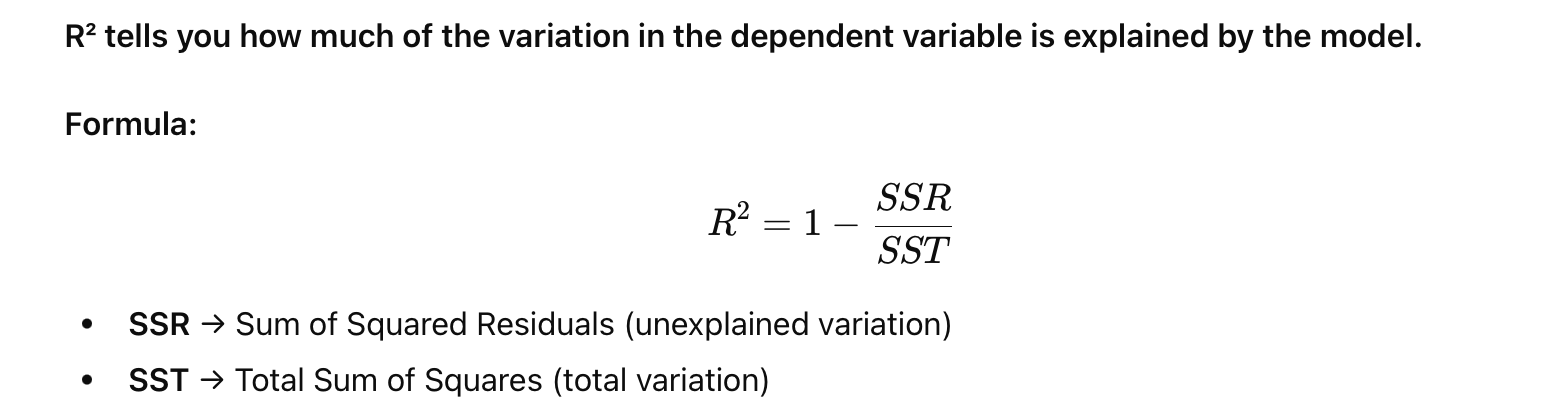

## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [98]:
from sklearn.metrics import r2_score

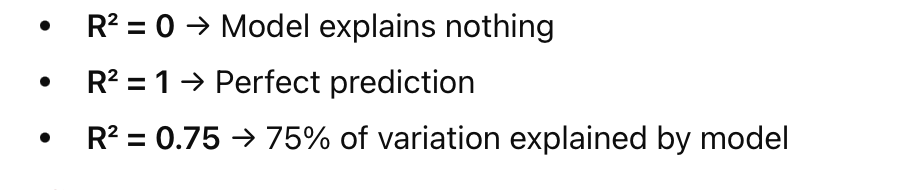

R² always increases when you add more variables —
even useless ones.
So:
Bigger R² ≠ Better model (always)

In [99]:
score=r2_score(y_test,y_pred)
print(score)

0.5857981324531034


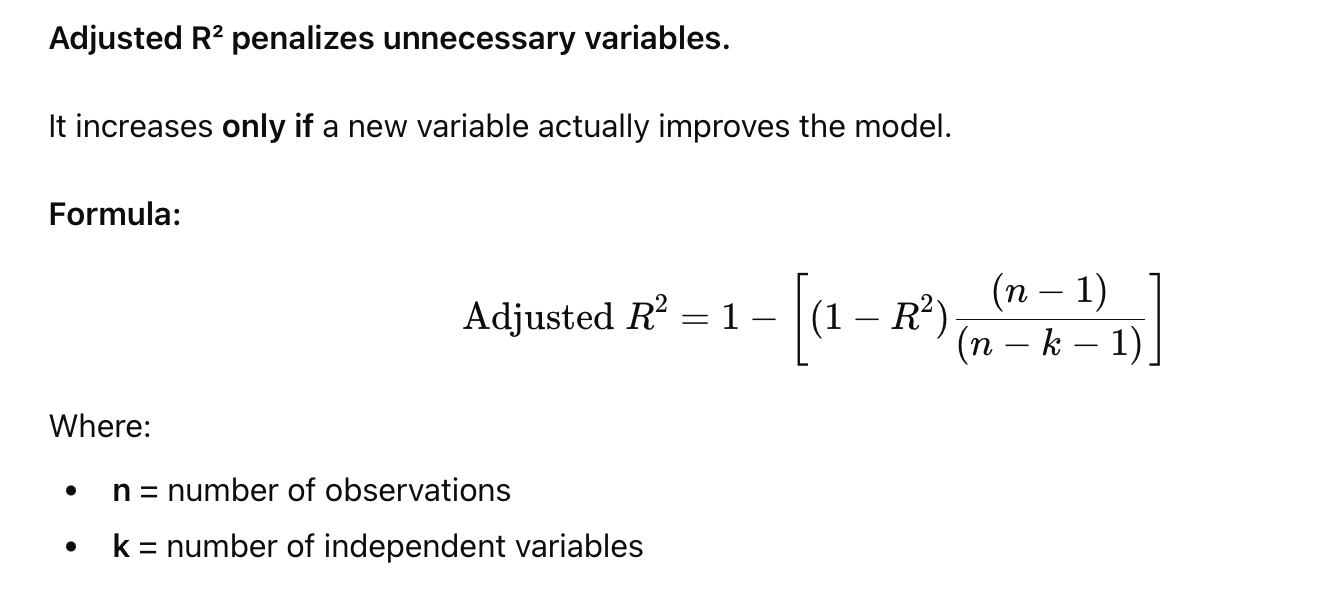

In [100]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5677893556032383

| Feature                       | R²                 | Adjusted R²                  |
| ----------------------------- | ------------------ | ---------------------------- |
| Measures                      | Explained variance | Penalized explained variance |
| Increases with more variables | Always             | Only if useful             |
| Best for                      | Simple regression  | Multiple regression          |
| Risk                          | Overfitting        | Reduced overfitting          |


R²: Proportion of variance in the dependent variable explained by the independent variables.
Adjusted R²: Modified R² that adjusts for the number of predictors to avoid overfitting.

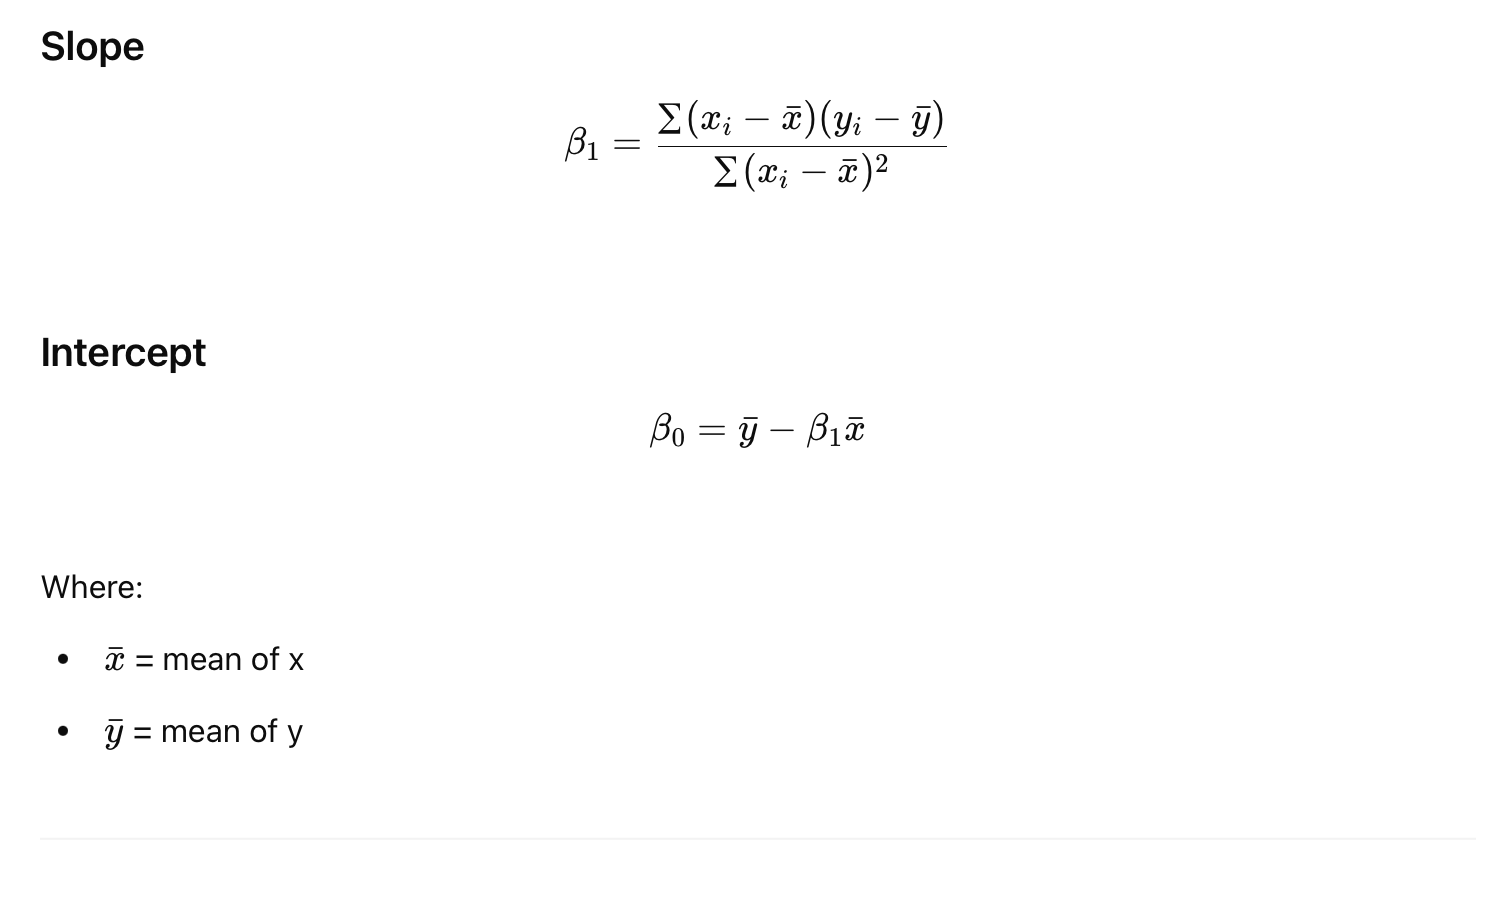

In [101]:
## OLS Linear Regression
import statsmodels.api as sm

In [102]:
model=sm.OLS(y_train,X_train).fit()

In [103]:
prediction=model.predict(X_test)
print(prediction)

62    38.880615
40    29.043351
95    34.196203
18    35.601527
97    31.385556
84    36.069968
64    35.601527
42    29.043351
10    19.674528
0     19.674528
31    36.538409
76    19.206087
47    38.412174
26    17.332322
44    39.349056
4     37.943732
22    16.395440
12    41.691262
88    41.222820
73    37.943732
49    26.701145
70    20.611410
68    35.601527
15    17.800763
39    22.953616
dtype: float64


In [104]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                    age   R-squared (uncentered):                   0.963
Model:                            OLS   Adj. R-squared (uncentered):              0.963
Method:                 Least Squares   F-statistic:                              1905.
Date:                Tue, 03 Feb 2026   Prob (F-statistic):                    4.77e-54
Time:                        14:45:45   Log-Likelihood:                         -240.16
No. Observations:                  74   AIC:                                      482.3
Df Residuals:                      73   BIC:                                      484.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [105]:
weight_p = float(input("Enter weight: "))
prediction = model.predict([weight_p])
print("Predicted age is:", prediction)


Predicted age is: [26.23270388]
